In [6]:
# start using the kernal
import os
from pycirclize import Circos
from pycirclize.parser import Gff
from pycirclize.utils import load_prokaryote_example_file
from pycirclize.parser import Genbank
from matplotlib.pyplot import imshow
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import pandas as pd



# os.chdir("/home/david/david/ellen/r_gnavus/snp_analysis/align_new_and_old/circular_genome_plot")

# Load Genbank file
# Assuming you have a dictionary mapping protein_ids to colors
protein_id_to_color = {
    'WP_153907241.1': 'black',
    'WP_153907239.1': '#8491B4FF',
    'WP_153907235.1': '#3C5488FF',
    # Add more mappings as needed
    'WP_001058290.1': 'black',
    'WP_044688097.1': '#8491B4FF',
    'WP_000344171.1': '#3C5488FF'
}

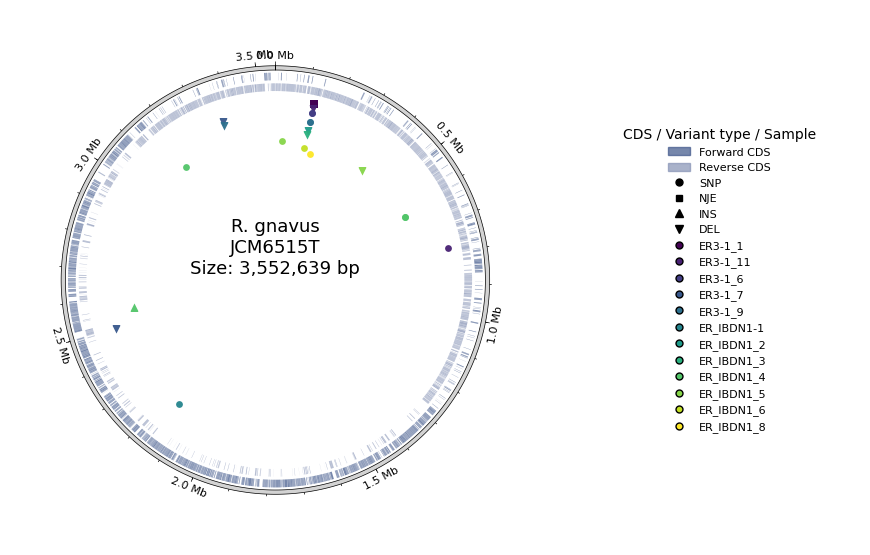

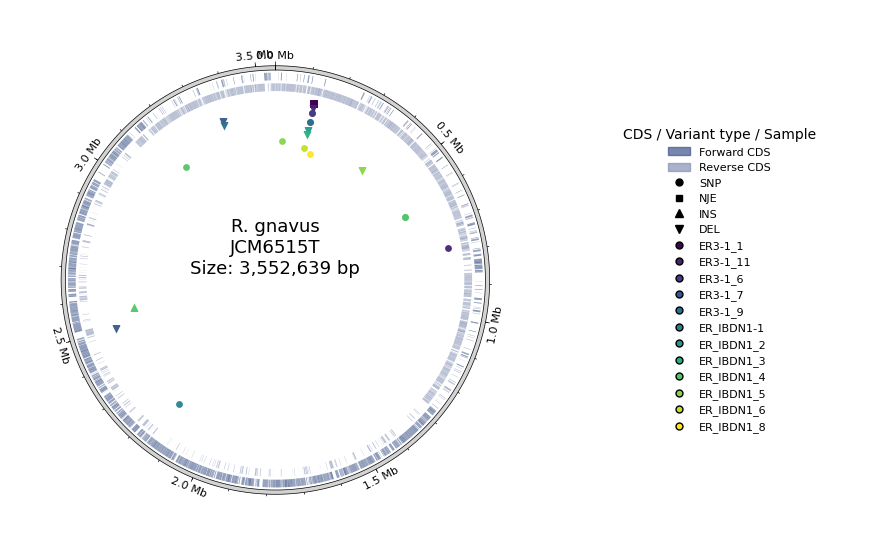

In [10]:
from pycirclize import Circos
from pycirclize.parser import Genbank
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib import colormaps
import os
import pandas as pd

# Load genome and final table
variants_df = pd.read_csv("final_table.tsv", sep="\t", dtype=str)
variants_df.columns = [c.strip() for c in variants_df.columns]

# Standardize expected column names
rename_map = {}
if "Locus Tag" in variants_df.columns:
    rename_map["Locus Tag"] = "Locus_Tag"
if "Gene Product" in variants_df.columns:
    rename_map["Gene Product"] = "Gene_Product"
if "Reference Sequence" in variants_df.columns:
    rename_map["Reference Sequence"] = "REF"
if "New Sequence" in variants_df.columns:
    rename_map["New Sequence"] = "ALT"
variants_df = variants_df.rename(columns=rename_map)

# Keep rows with required values
required_cols = ["Mutant", "Type", "Gene_Add", "Locus_Tag"]
missing_cols = [c for c in required_cols if c not in variants_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in final_table.tsv: {missing_cols}")

variants_df["Gene_Add"] = pd.to_numeric(variants_df["Gene_Add"], errors="coerce")
variants_df = variants_df.loc[variants_df["Gene_Add"].notna()].copy()

# Parse locus tags (some rows contain multiple tags separated by '/')
variants_df["Locus_Tag_primary"] = (
    variants_df["Locus_Tag"]
    .fillna("")
    .astype(str)
    .str.split("/")
    .str[0]
    .str.strip()
)

# Load GenBank and build locus_tag -> gene start mapping
gbk_file = os.path.join("JCM6515T_spades_scaffold_circular.current.gb")
gbk = Genbank(gbk_file)

locus_start = {}
for feature in gbk.extract_features("CDS"):
    qualifiers = getattr(feature, "qualifiers", {})
    tags = qualifiers.get("locus_tag", []) if qualifiers else []
    if not tags:
        continue
    start_pos = int(feature.location.start) + 1
    for tag in tags:
        locus_start[str(tag).strip()] = start_pos

# Compute closed-genome position = gene start + Gene_Add
variants_df["Gene_Start"] = variants_df["Locus_Tag_primary"].map(locus_start)
variants_df["POS"] = variants_df["Gene_Start"] + variants_df["Gene_Add"]

# Drop rows where locus tag was not found in GenBank
variants_df = variants_df.loc[variants_df["POS"].notna()].copy()
variants_df["POS"] = variants_df["POS"].astype(int)

# Build columns expected by plotting code
variants_df["Sample"] = variants_df["Mutant"].astype(str).str.strip()
variants_df["Type"] = variants_df["Type"].fillna("").astype(str).str.strip().str.upper()
if "REF" not in variants_df.columns:
    variants_df["REF"] = ""
if "ALT" not in variants_df.columns:
    variants_df["ALT"] = ""
variants_df["REF"] = variants_df["REF"].fillna("").astype(str)
variants_df["ALT"] = variants_df["ALT"].fillna("").astype(str)

# Marker mapping by variant type
type_marker_map = {
    "SNP": "o",
    "NJE": "s",
    "INS": "^",
    "DEL": "v",
}
type_size_map = {
    "SNP": 24,
    "NJE": 28,
    "INS": 34,
    "DEL": 34,
}

plasmid_size = gbk.range_size
formatted_plasmid_size = f"{plasmid_size:,}"

strain_order = sorted(variants_df["Sample"].dropna().unique())
viridis = colormaps["viridis"]
strain_colors = {
    strain: viridis(i / max(len(strain_order) - 1, 1))
    for i, strain in enumerate(strain_order)
}

circos = Circos(sectors={gbk.name: gbk.range_size})
circos.text(
    f"\nR. gnavus\nJCM6515T\nSize: {formatted_plasmid_size} bp",
    size=13,
    r=20,
)
sector = circos.get_sector(gbk.name)

# Plot outer coordinate track
major_ticks_interval = 500000
minor_ticks_interval = 100000
outer_track = sector.add_track((98, 100))
outer_track.axis(fc="lightgrey")
outer_track.xticks_by_interval(
    major_ticks_interval, label_formatter=lambda v: f"{v / 10 ** 6:.1f} Mb"
)
outer_track.xticks_by_interval(minor_ticks_interval, tick_length=1, show_label=False)

# Plot coding sequences
f_cds_track = sector.add_track((93, 97), r_pad_ratio=0.1)
f_cds_track.genomic_features(gbk.extract_features("CDS", target_strand=1), fc="#3C5488B2")

r_cds_track = sector.add_track((88, 92), r_pad_ratio=0.1)
r_cds_track.genomic_features(gbk.extract_features("CDS", target_strand=-1), fc="#8491B4B2")

# Plot one variant track per sample
track_outer = 84.0
track_height = 1.9
track_gap = 0.2

for idx, strain in enumerate(strain_order):
    top = track_outer - idx * (track_height + track_gap)
    bottom = top - track_height
    if bottom <= 22:
        raise ValueError(
            f"Not enough radial space for {len(strain_order)} sample tracks. "
            "Reduce the number of samples or shrink track spacing."
        )

    strain_df = variants_df.loc[variants_df["Sample"] == strain].sort_values("POS")
    strain_track = sector.add_track((bottom, top), r_pad_ratio=0.02)
    strain_track.axis(fc="none", ec="none")

    for vtype, marker in type_marker_map.items():
        type_df = strain_df.loc[strain_df["Type"] == vtype]
        if type_df.empty:
            continue
        strain_track.scatter(
            type_df["POS"].tolist(),
            [1.0] * len(type_df),
            vmin=0,
            vmax=1,
            color=strain_colors[strain],
            s=type_size_map[vtype],
            alpha=0.95,
            marker=marker,
            tooltip=[
                f"{strain}: {vt} POS {pos} | {ref}>{alt}"
                for pos, ref, alt, vt in zip(
                    type_df["POS"],
                    type_df["REF"],
                    type_df["ALT"],
                    type_df["Type"],
                )
            ],
        )

fig = circos.plotfig()

variant_handles = [
    Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=5, label="SNP"),
    Line2D([0], [0], marker="s", color="black", linestyle="None", markersize=5, label="NJE"),
    Line2D([0], [0], marker="^", color="black", linestyle="None", markersize=6, label="INS"),
    Line2D([0], [0], marker="v", color="black", linestyle="None", markersize=6, label="DEL"),
]
cds_handles = [
    Patch(color="#3C5488B2", label="Forward CDS"),
    Patch(color="#8491B4B2", label="Reverse CDS"),
]
strain_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=strain_colors[strain],
        markersize=5,
        label=strain,
    )
    for strain in strain_order
]

_ = circos.ax.legend(
    handles=cds_handles + variant_handles + strain_handles,
    bbox_to_anchor=(1.25, 0.5),
    loc="center left",
    fontsize=8,
    frameon=False,
    title="CDS / Variant type / Sample",
)
fig.patch.set_facecolor("none")
fig.patch.set_alpha(0)
circos.ax.set_facecolor("none")

fig.savefig(
    "JCM6515T_all_variants_tracks_by_sample_final_table.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)
fig.savefig("JCM6515T_all_variants_tracks_by_sample_final_table.png", dpi=300, bbox_inches="tight")

# Second rendering with same type-specific markers
circos = Circos(sectors={gbk.name: gbk.range_size})
circos.text(f"\nR. gnavus\nJCM6515T\nSize: {formatted_plasmid_size} bp", size=13, r=20)
sector = circos.get_sector(gbk.name)

coord_track = sector.add_track((98, 100))
coord_track.axis(fc="lightgrey")
coord_track.xticks_by_interval(major_ticks_interval, label_formatter=lambda v: f"{v / 10**6:.1f} Mb")
coord_track.xticks_by_interval(minor_ticks_interval, tick_length=1, show_label=False)

sector.add_track((93, 97), r_pad_ratio=0.1).genomic_features(
    gbk.extract_features("CDS", target_strand=1), fc="#3C5488B2"
)
sector.add_track((88, 92), r_pad_ratio=0.1).genomic_features(
    gbk.extract_features("CDS", target_strand=-1), fc="#8491B4B2"
)

for i, s in enumerate(strain_order):
    t = track_outer - i * (track_height + track_gap)
    b = t - track_height
    tr = sector.add_track((b, t), r_pad_ratio=0.02)
    tr.axis(fc="none", ec="none")

    sdf = variants_df.loc[variants_df["Sample"] == s].sort_values("POS")

    for vtype, marker in type_marker_map.items():
        tdf = sdf.loc[sdf["Type"] == vtype]
        if tdf.empty:
            continue
        tr.scatter(
            tdf["POS"].tolist(),
            [1.0] * len(tdf),
            color=strain_colors[s],
            s=type_size_map[vtype],
            alpha=0.95,
            marker=marker,
            tooltip=[
                f"{s}: {vt} POS {p} | {r}>{a}"
                for p, r, a, vt in zip(tdf["POS"], tdf["REF"], tdf["ALT"], tdf["Type"])
            ],
        )

fig = circos.plotfig()

_ = circos.ax.legend(
    handles=cds_handles + variant_handles + strain_handles,
    bbox_to_anchor=(1.25, 0.5),
    loc="center left",
    fontsize=8,
    frameon=False,
    title="CDS / Variant type / Sample",
)

fig.savefig("JCM6515T_all_variants_tracks_by_sample_final_table_types.svg", format="svg", transparent=True, bbox_inches="tight")
fig.savefig("JCM6515T_all_variants_tracks_by_sample_final_table_types.png", dpi=300, bbox_inches="tight")